In [1]:
# What this cell does:
# Import all libraries required for final model evaluation,
# visualization, metrics, and loading the trained models.

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# What this cell does:
# Load the final engineered datasets created in Notebook 05.
# These datasets contain the 14 ML features and TARGET_AC_POWER.

plant1 = pd.read_csv("../data/final/plant1_features.csv")
plant2 = pd.read_csv("../data/final/plant2_features.csv")

plant1["DATE_TIME"] = pd.to_datetime(plant1["DATE_TIME"])
plant2["DATE_TIME"] = pd.to_datetime(plant2["DATE_TIME"])

print("Plant 1 shape:", plant1.shape)
print("Plant 2 shape:", plant2.shape)

Plant 1 shape: (66337, 27)
Plant 2 shape: (65466, 27)


In [3]:
# What this cell does:
# Define the exact feature set and target used during model training.
# Keeping the same feature order is important when loading saved models.

feature_columns = [
    "hour",
    "minute",
    "day",
    "day_of_week",
    "day_of_year",
    "month",
    "hour_sin",
    "hour_cos",
    "AC_POWER_lag_1",
    "AC_POWER_lag_4",
    "AC_POWER_lag_8",
    "AC_POWER_lag_96",
    "AC_POWER_rolling_mean_4",
    "AC_POWER_rolling_mean_8"
]

target_column = "TARGET_AC_POWER"

print("Number of features:", len(feature_columns))
print("Target:", target_column)

Number of features: 14
Target: TARGET_AC_POWER


In [4]:
# What this cell does:
# Recreate the exact chronological train/validation/test split
# used during model training.
#
# No random shuffling is used because this is a time-series problem.

def chronological_split(df, train_ratio=0.70, val_ratio=0.15):
    """Split chronologically and remove rows whose target crosses a cutoff."""
    df = df.sort_values("DATE_TIME").copy()
    unique_times = np.sort(df["DATE_TIME"].unique())
    n_times = len(unique_times)
    train_end = int(n_times * train_ratio)
    val_end = int(n_times * (train_ratio + val_ratio))
    train_end_time = pd.Timestamp(unique_times[train_end])
    val_end_time = pd.Timestamp(unique_times[val_end])
    target_time = df["DATE_TIME"] + pd.Timedelta(minutes=15)

    train = df[(df["DATE_TIME"] < train_end_time) & (target_time < train_end_time)].copy()
    validation = df[
        (df["DATE_TIME"] >= train_end_time)
        & (df["DATE_TIME"] < val_end_time)
        & (target_time < val_end_time)
    ].copy()
    test = df[df["DATE_TIME"] >= val_end_time].copy()
    return train, validation, test

In [5]:
# What this cell does:
# Create the final unseen test datasets for both plants.
# Only the test period will be used for final model evaluation.

plant1_train, plant1_val, plant1_test = chronological_split(plant1)
plant2_train, plant2_val, plant2_test = chronological_split(plant2)

print("Plant 1 test:", plant1_test.shape)
print("Plant 2 test:", plant2_test.shape)

print("\nPlant 1 test period:")
print(
    plant1_test["DATE_TIME"].min(),
    "→",
    plant1_test["DATE_TIME"].max()
)

print("\nPlant 2 test period:")
print(
    plant2_test["DATE_TIME"].min(),
    "→",
    plant2_test["DATE_TIME"].max()
)

Plant 1 test: (10076, 27)
Plant 2 test: (10428, 27)

Plant 1 test period:
2020-06-13 04:30:00 → 2020-06-17 23:30:00

Plant 2 test period:
2020-06-13 01:15:00 → 2020-06-17 23:30:00


In [6]:
# What this cell does:
# Extract the 14 input features and the target variable
# from the untouched test period.

X1_test = plant1_test[feature_columns]
y1_test = plant1_test[target_column]

X2_test = plant2_test[feature_columns]
y2_test = plant2_test[target_column]

print("Plant 1 X_test:", X1_test.shape)
print("Plant 1 y_test:", y1_test.shape)

print("\nPlant 2 X_test:", X2_test.shape)
print("Plant 2 y_test:", y2_test.shape)

Plant 1 X_test: (10076, 14)
Plant 1 y_test: (10076,)

Plant 2 X_test: (10428, 14)
Plant 2 y_test: (10428,)


In [7]:
# What this cell does:
# Load the trained Linear Regression, Random Forest,
# and XGBoost models saved from Notebook 07.
#
# We load the models instead of retraining them.

MODEL_PATH = "../models/"

linear_model_plant1 = joblib.load(
    MODEL_PATH + "linear_regression/plant1_model.pkl"
)

linear_model_plant2 = joblib.load(
    MODEL_PATH + "linear_regression/plant2_model.pkl"
)

rf_model_plant1 = joblib.load(
    MODEL_PATH + "random_forest/plant1_model.pkl"
)

rf_model_plant2 = joblib.load(
    MODEL_PATH + "random_forest/plant2_model.pkl"
)

xgb_model_plant1 = joblib.load(
    MODEL_PATH + "xgboost/plant1_model.pkl"
)

xgb_model_plant2 = joblib.load(
    MODEL_PATH + "xgboost/plant2_model.pkl"
)

print("All trained models loaded successfully.")

All trained models loaded successfully.


In [8]:
# What this cell does:
# Generate final predictions on the completely unseen test period
# using all three trained ML models.

# Plant 1
plant1_test["Persistence"] = plant1_test["AC_POWER"]

plant1_test["Linear_Regression"] = (
    linear_model_plant1.predict(X1_test)
)

plant1_test["Random_Forest"] = (
    rf_model_plant1.predict(X1_test)
)

plant1_test["XGBoost"] = (
    xgb_model_plant1.predict(X1_test)
)


# Plant 2
plant2_test["Persistence"] = plant2_test["AC_POWER"]

plant2_test["Linear_Regression"] = (
    linear_model_plant2.predict(X2_test)
)

plant2_test["Random_Forest"] = (
    rf_model_plant2.predict(X2_test)
)

plant2_test["XGBoost"] = (
    xgb_model_plant2.predict(X2_test)
)

print("Test predictions generated successfully.")

Test predictions generated successfully.


In [9]:
# What this cell does:
# Check that every model produced the expected number of
# predictions and inspect a few actual versus predicted values.

print("Plant 1:")
display(
    plant1_test[
        [
            "DATE_TIME",
            "TARGET_AC_POWER",
            "Persistence",
            "Linear_Regression",
            "Random_Forest",
            "XGBoost"
        ]
    ].head()
)

print("\nPlant 2:")
display(
    plant2_test[
        [
            "DATE_TIME",
            "TARGET_AC_POWER",
            "Persistence",
            "Linear_Regression",
            "Random_Forest",
            "XGBoost"
        ]
    ].head()
)

Plant 1:


,DATE_TIME,TARGET_AC_POWER,Persistence,Linear_Regression,Random_Forest,XGBoost
2589,2020-06-13 04:30:00,0.0,0.0,73.250357,0.0,0.724263
23665,2020-06-13 04:30:00,0.0,0.0,73.250357,0.0,0.724263
14641,2020-06-13 04:30:00,0.0,0.0,73.250357,0.0,0.724263
56848,2020-06-13 04:30:00,0.0,0.0,73.250357,0.0,0.724263
35752,2020-06-13 04:30:00,0.0,0.0,73.250357,0.0,0.724263



Plant 2:


,DATE_TIME,TARGET_AC_POWER,Persistence,Linear_Regression,Random_Forest,XGBoost
20597,2020-06-13 01:15:00,0.0,0.0,-27.973576,0.0,0.194694
59581,2020-06-13 01:15:00,0.0,0.0,-27.973576,0.0,0.194694
50107,2020-06-13 01:15:00,0.0,0.0,-27.973576,0.0,0.194694
32194,2020-06-13 01:15:00,0.0,0.0,-27.973576,0.0,0.194694
8935,2020-06-13 01:15:00,0.0,0.0,-27.973576,0.0,0.194694


In [10]:
# What this cell does:
# Evaluate all forecasting approaches on the completely unseen
# test period using MAE, RMSE and R².

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2


# Plant 1
p1_persistence = calculate_metrics(
    y1_test, plant1_test["Persistence"]
)

p1_linear = calculate_metrics(
    y1_test, plant1_test["Linear_Regression"]
)

p1_rf = calculate_metrics(
    y1_test, plant1_test["Random_Forest"]
)

p1_xgb = calculate_metrics(
    y1_test, plant1_test["XGBoost"]
)


# Plant 2
p2_persistence = calculate_metrics(
    y2_test, plant2_test["Persistence"]
)

p2_linear = calculate_metrics(
    y2_test, plant2_test["Linear_Regression"]
)

p2_rf = calculate_metrics(
    y2_test, plant2_test["Random_Forest"]
)

p2_xgb = calculate_metrics(
    y2_test, plant2_test["XGBoost"]
)


print("Plant 1 - Test Results")
print("Persistence       MAE:", p1_persistence[0],
      "RMSE:", p1_persistence[1],
      "R²:", p1_persistence[2])

print("Linear Regression MAE:", p1_linear[0],
      "RMSE:", p1_linear[1],
      "R²:", p1_linear[2])

print("Random Forest     MAE:", p1_rf[0],
      "RMSE:", p1_rf[1],
      "R²:", p1_rf[2])

print("XGBoost           MAE:", p1_xgb[0],
      "RMSE:", p1_xgb[1],
      "R²:", p1_xgb[2])


print("\nPlant 2 - Test Results")
print("Persistence       MAE:", p2_persistence[0],
      "RMSE:", p2_persistence[1],
      "R²:", p2_persistence[2])

print("Linear Regression MAE:", p2_linear[0],
      "RMSE:", p2_linear[1],
      "R²:", p2_linear[2])

print("Random Forest     MAE:", p2_rf[0],
      "RMSE:", p2_rf[1],
      "R²:", p2_rf[2])

print("XGBoost           MAE:", p2_xgb[0],
      "RMSE:", p2_xgb[1],
      "R²:", p2_xgb[2])

Plant 1 - Test Results
Persistence       MAE: 60.149400095316196 RMSE: 113.23179349217021 R²: 0.9112735485175332
Linear Regression MAE: 85.72737105390412 RMSE: 131.52472443432185 R²: 0.8802898041252659
Random Forest     MAE: 74.73204116582463 RMSE: 141.51256411144143 R²: 0.8614181544776096
XGBoost           MAE: 74.50866733281771 RMSE: 144.2734102922987 R²: 0.8559580687425377

Plant 2 - Test Results
Persistence       MAE: 64.05312181489397 RMSE: 132.3360489385585 R²: 0.8029120790256988
Linear Regression MAE: 86.62978634153883 RMSE: 149.62770481474277 R²: 0.7480422574791379
Random Forest     MAE: 73.99980215184434 RMSE: 149.3925261706745 R²: 0.7488336685748097
XGBoost           MAE: 72.08698674422368 RMSE: 148.23421841979552 R²: 0.752713381544666


In [11]:
# What this cell does:
# Put all final test metrics into one clean table.

test_results = pd.DataFrame({
    "Plant": [
        "Plant 1", "Plant 1", "Plant 1", "Plant 1",
        "Plant 2", "Plant 2", "Plant 2", "Plant 2"
    ],

    "Model": [
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        p1_persistence[0],
        p1_linear[0],
        p1_rf[0],
        p1_xgb[0],
        p2_persistence[0],
        p2_linear[0],
        p2_rf[0],
        p2_xgb[0]
    ],

    "RMSE": [
        p1_persistence[1],
        p1_linear[1],
        p1_rf[1],
        p1_xgb[1],
        p2_persistence[1],
        p2_linear[1],
        p2_rf[1],
        p2_xgb[1]
    ],

    "R2": [
        p1_persistence[2],
        p1_linear[2],
        p1_rf[2],
        p1_xgb[2],
        p2_persistence[2],
        p2_linear[2],
        p2_rf[2],
        p2_xgb[2]
    ]
})

test_results

,Plant,Model,MAE,RMSE,R2
0,Plant 1,Persistence,60.149400,113.231793,0.911274
1,Plant 1,Linear Regression,85.727371,131.524724,0.880290
2,Plant 1,Random Forest,74.732041,141.512564,0.861418
3,Plant 1,XGBoost,74.508667,144.273410,0.855958
4,Plant 2,Persistence,64.053122,132.336049,0.802912
5,Plant 2,Linear Regression,86.629786,149.627705,0.748042
6,Plant 2,Random Forest,73.999802,149.392526,0.748834
7,Plant 2,XGBoost,72.086987,148.234218,0.752713


In [12]:
# What this cell does:
# Save the final test metrics for the report and later notebooks.

METRICS_PATH = "../outputs/metrics/"
os.makedirs(METRICS_PATH, exist_ok=True)

test_results.to_csv(
    METRICS_PATH + "test_model_results.csv",
    index=False
)

print("Final test metrics saved successfully.")

Final test metrics saved successfully.


In [13]:
# What this cell does:
# Save actual target values and all model predictions.
# These predictions will be used for residual analysis,
# actual-vs-predicted plots, and time-based evaluation.

PREDICTIONS_PATH = "../outputs/predictions/"
os.makedirs(PREDICTIONS_PATH, exist_ok=True)

plant1_test[
    [
        "DATE_TIME",
        "PLANT_ID",
        "SOURCE_KEY",
        "AC_POWER",
        "TARGET_AC_POWER",
        "Persistence",
        "Linear_Regression",
        "Random_Forest",
        "XGBoost"
    ]
].to_csv(
    PREDICTIONS_PATH + "plant1_test_predictions.csv",
    index=False
)

plant2_test[
    [
        "DATE_TIME",
        "PLANT_ID",
        "SOURCE_KEY",
        "AC_POWER",
        "TARGET_AC_POWER",
        "Persistence",
        "Linear_Regression",
        "Random_Forest",
        "XGBoost"
    ]
].to_csv(
    PREDICTIONS_PATH + "plant2_test_predictions.csv",
    index=False
)

print("Test predictions saved successfully.")

Test predictions saved successfully.


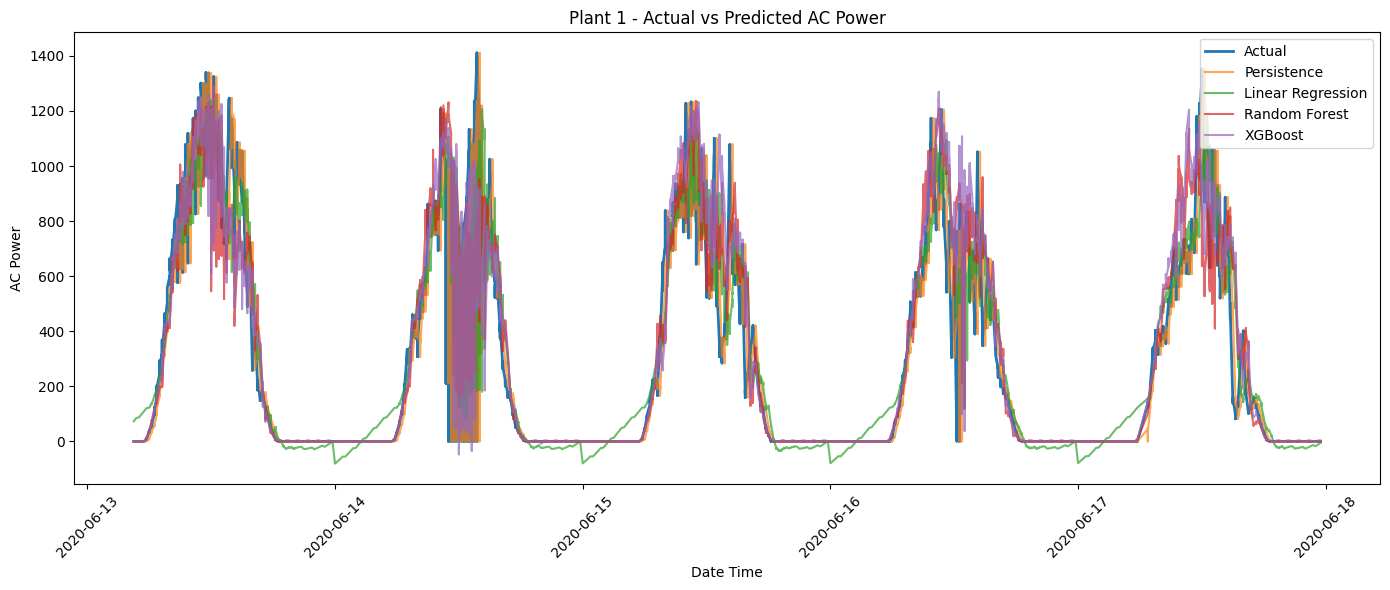

In [14]:
# What this cell does:
# Compare actual 15-minute-ahead AC power with predictions
# from Persistence, Linear Regression, Random Forest and XGBoost.

plt.figure(figsize=(14, 6))

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["TARGET_AC_POWER"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["Persistence"],
    label="Persistence",
    alpha=0.7
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["Linear_Regression"],
    label="Linear Regression",
    alpha=0.7
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["Random_Forest"],
    label="Random Forest",
    alpha=0.7
)

plt.plot(
    plant1_test["DATE_TIME"],
    plant1_test["XGBoost"],
    label="XGBoost",
    alpha=0.7
)

plt.xlabel("Date Time")
plt.ylabel("AC Power")
plt.title("Plant 1 - Actual vs Predicted AC Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

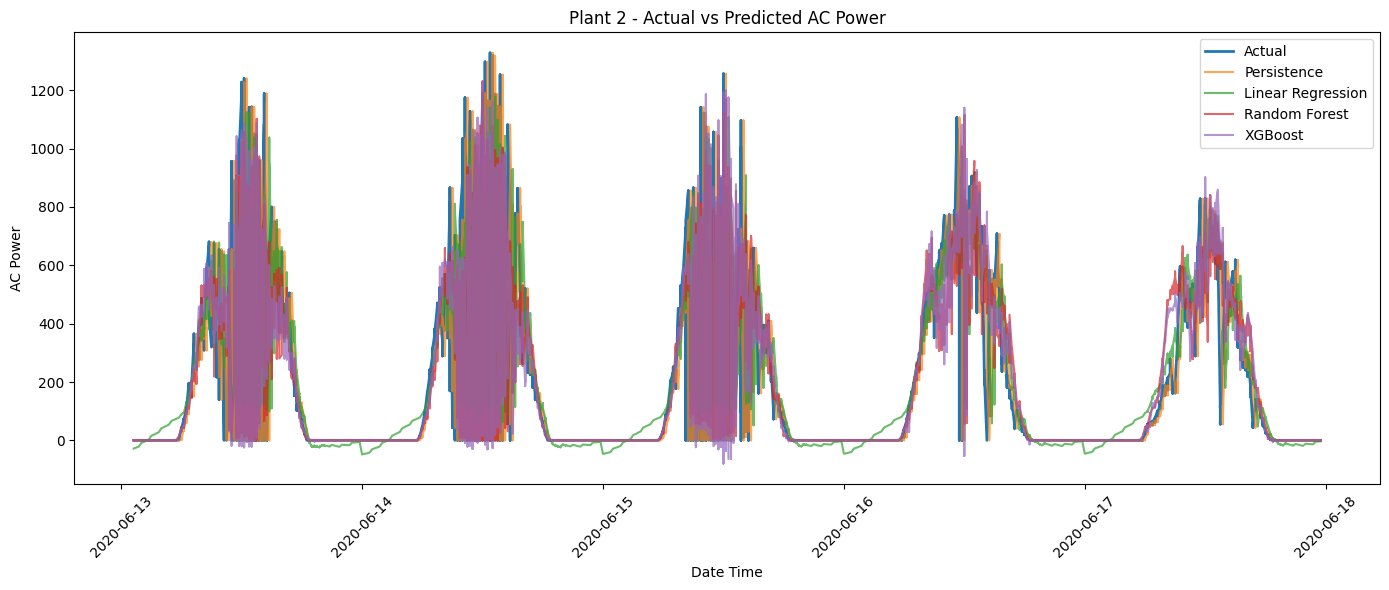

In [15]:
# What this cell does:
# Compare actual and predicted AC power for Plant 2.

plt.figure(figsize=(14, 6))

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["TARGET_AC_POWER"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["Persistence"],
    label="Persistence",
    alpha=0.7
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["Linear_Regression"],
    label="Linear Regression",
    alpha=0.7
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["Random_Forest"],
    label="Random Forest",
    alpha=0.7
)

plt.plot(
    plant2_test["DATE_TIME"],
    plant2_test["XGBoost"],
    label="XGBoost",
    alpha=0.7
)

plt.xlabel("Date Time")
plt.ylabel("AC Power")
plt.title("Plant 2 - Actual vs Predicted AC Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# What this cell does:
# Calculate prediction errors (residuals) for every model.
#
# Residual = Actual - Predicted
#
# A residual close to zero means the prediction is close
# to the actual AC power.

# Plant 1
plant1_test["Persistence_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["Persistence"]
)

plant1_test["Linear_Regression_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["Linear_Regression"]
)

plant1_test["Random_Forest_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["Random_Forest"]
)

plant1_test["XGBoost_Error"] = (
    plant1_test["TARGET_AC_POWER"] - plant1_test["XGBoost"]
)


# Plant 2
plant2_test["Persistence_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["Persistence"]
)

plant2_test["Linear_Regression_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["Linear_Regression"]
)

plant2_test["Random_Forest_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["Random_Forest"]
)

plant2_test["XGBoost_Error"] = (
    plant2_test["TARGET_AC_POWER"] - plant2_test["XGBoost"]
)

print("Residuals calculated successfully.")

Residuals calculated successfully.


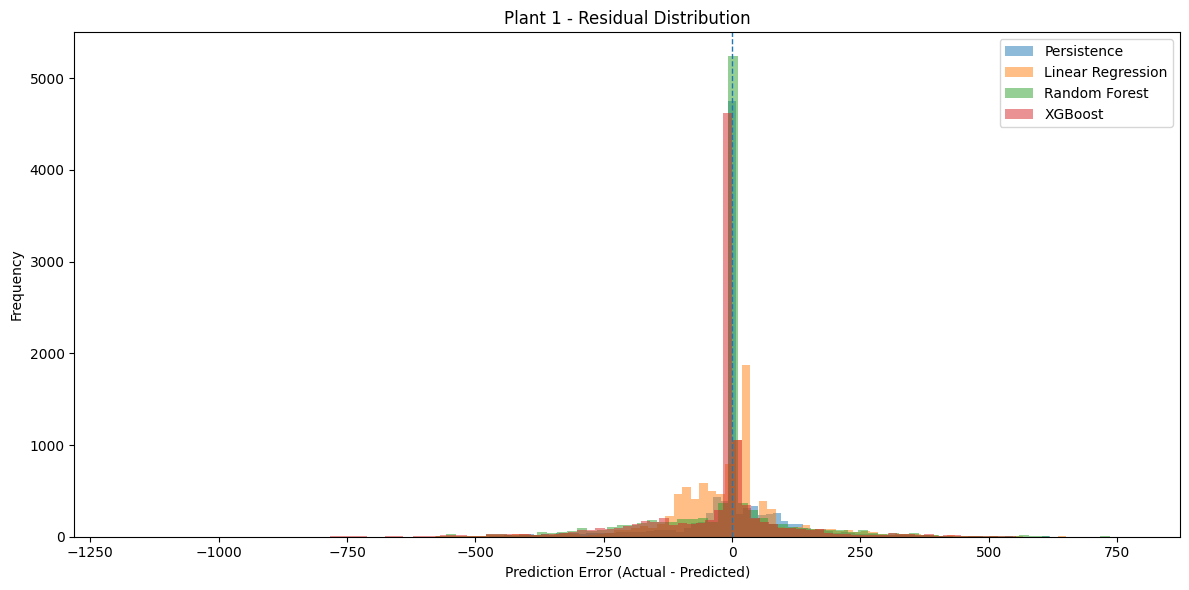

In [17]:
# What this cell does:
# Visualize the distribution of prediction errors
# for Plant 1.

plt.figure(figsize=(12, 6))

plt.hist(
    plant1_test["Persistence_Error"],
    bins=100,
    alpha=0.5,
    label="Persistence"
)

plt.hist(
    plant1_test["Linear_Regression_Error"],
    bins=100,
    alpha=0.5,
    label="Linear Regression"
)

plt.hist(
    plant1_test["Random_Forest_Error"],
    bins=100,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    plant1_test["XGBoost_Error"],
    bins=100,
    alpha=0.5,
    label="XGBoost"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Plant 1 - Residual Distribution")
plt.legend()
plt.tight_layout()
plt.show()

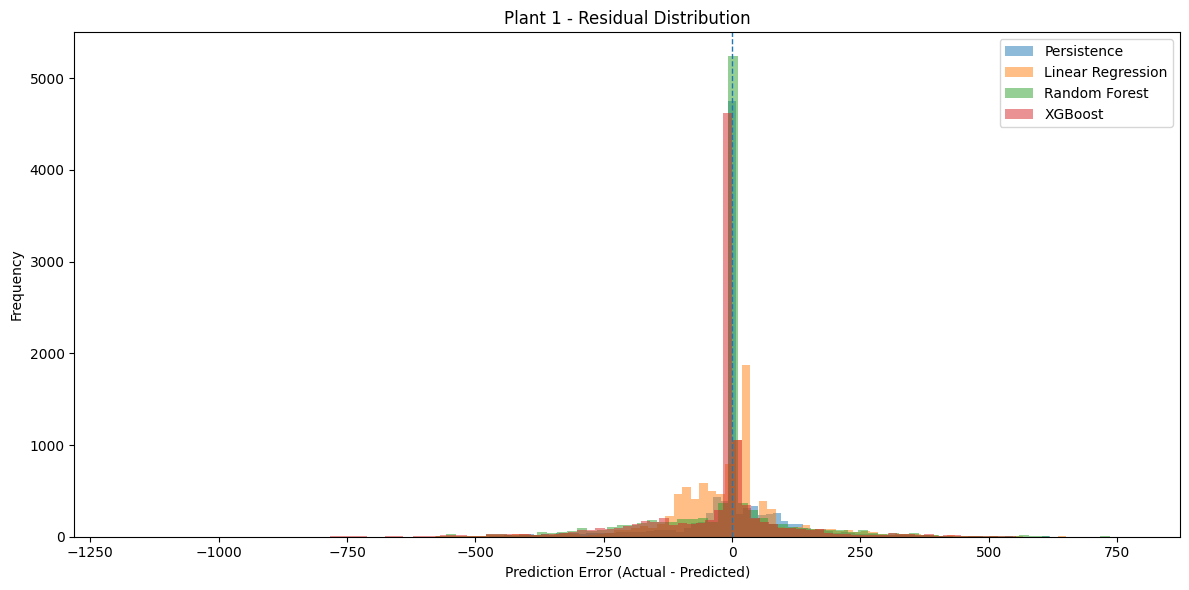

In [18]:
# What this cell does:
# Visualize the distribution of prediction errors
# for Plant 1.

plt.figure(figsize=(12, 6))

plt.hist(
    plant1_test["Persistence_Error"],
    bins=100,
    alpha=0.5,
    label="Persistence"
)

plt.hist(
    plant1_test["Linear_Regression_Error"],
    bins=100,
    alpha=0.5,
    label="Linear Regression"
)

plt.hist(
    plant1_test["Random_Forest_Error"],
    bins=100,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    plant1_test["XGBoost_Error"],
    bins=100,
    alpha=0.5,
    label="XGBoost"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Plant 1 - Residual Distribution")
plt.legend()
plt.tight_layout()
plt.show()

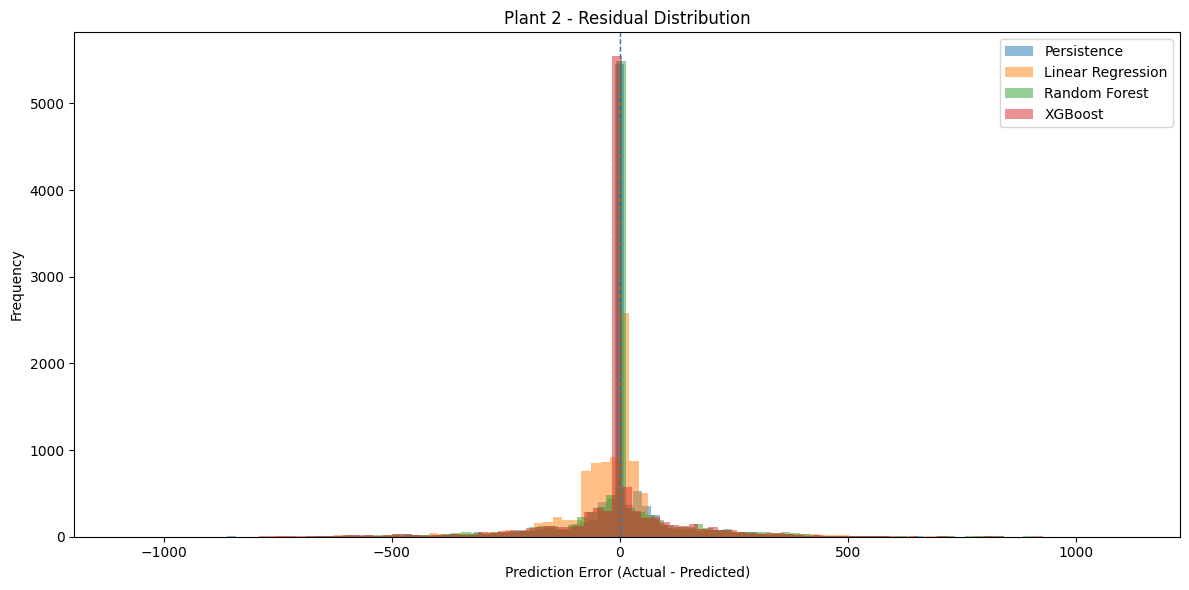

In [19]:
# What this cell does:
# Visualize the distribution of prediction errors
# for Plant 2.

plt.figure(figsize=(12, 6))

plt.hist(
    plant2_test["Persistence_Error"],
    bins=100,
    alpha=0.5,
    label="Persistence"
)

plt.hist(
    plant2_test["Linear_Regression_Error"],
    bins=100,
    alpha=0.5,
    label="Linear Regression"
)

plt.hist(
    plant2_test["Random_Forest_Error"],
    bins=100,
    alpha=0.5,
    label="Random Forest"
)

plt.hist(
    plant2_test["XGBoost_Error"],
    bins=100,
    alpha=0.5,
    label="XGBoost"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Plant 2 - Residual Distribution")
plt.legend()
plt.tight_layout()
plt.show()

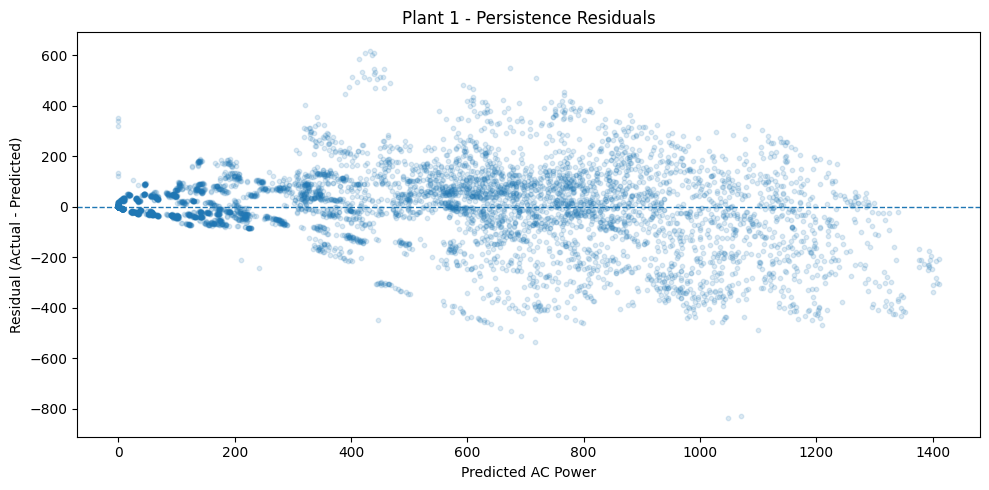

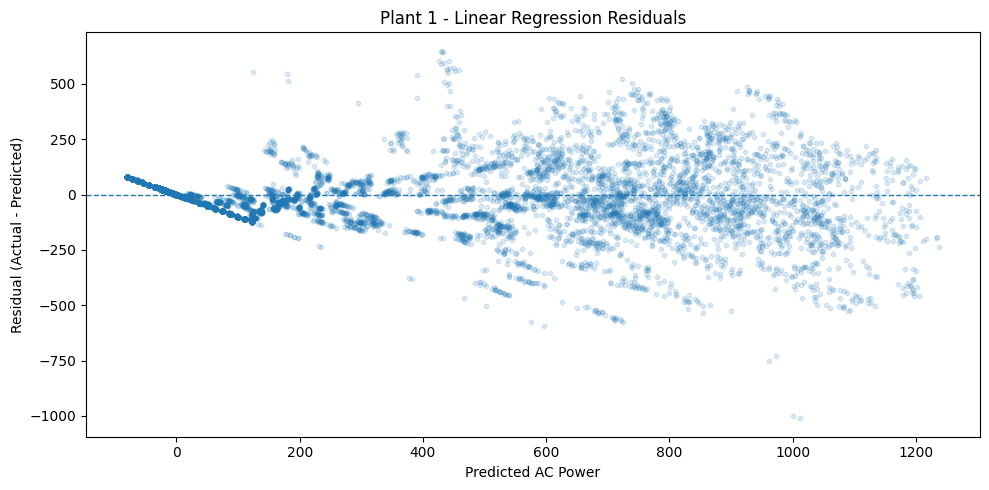

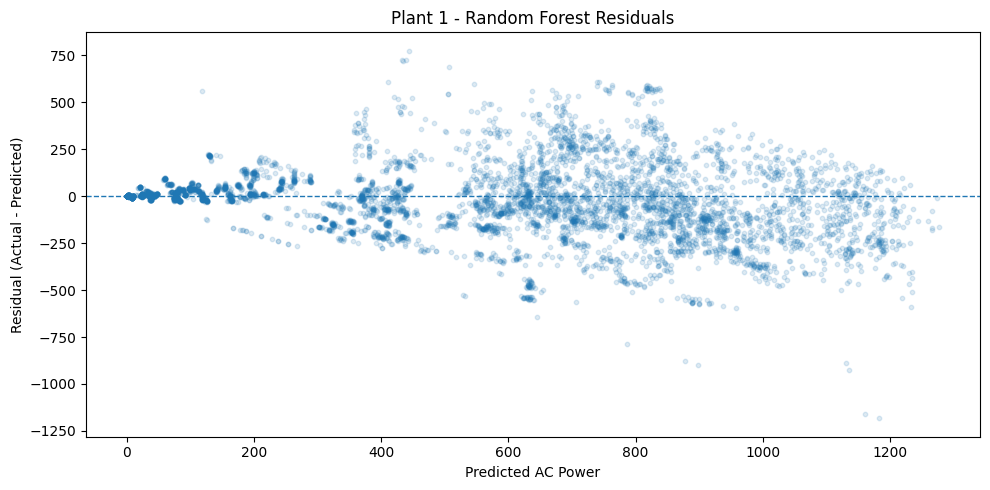

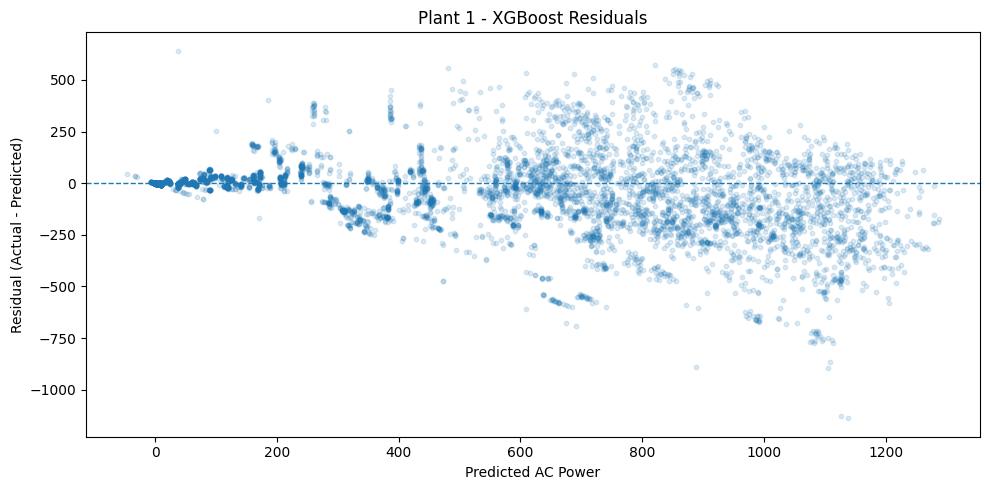

In [20]:
# What this cell does:
# Plot prediction residuals against predicted AC power.
#
# Residual = Actual - Predicted
#
# This helps us identify whether errors increase
# when the predicted solar power becomes higher.

models = [
    ("Persistence", "Persistence", "Persistence_Error"),
    ("Linear Regression", "Linear_Regression", "Linear_Regression_Error"),
    ("Random Forest", "Random_Forest", "Random_Forest_Error"),
    ("XGBoost", "XGBoost", "XGBoost_Error")
]

for model_name, prediction_column, error_column in models:

    plt.figure(figsize=(10, 5))

    plt.scatter(
        plant1_test[prediction_column],
        plant1_test[error_column],
        alpha=0.15,
        s=10
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Predicted AC Power")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"Plant 1 - {model_name} Residuals")
    plt.tight_layout()
    plt.show()

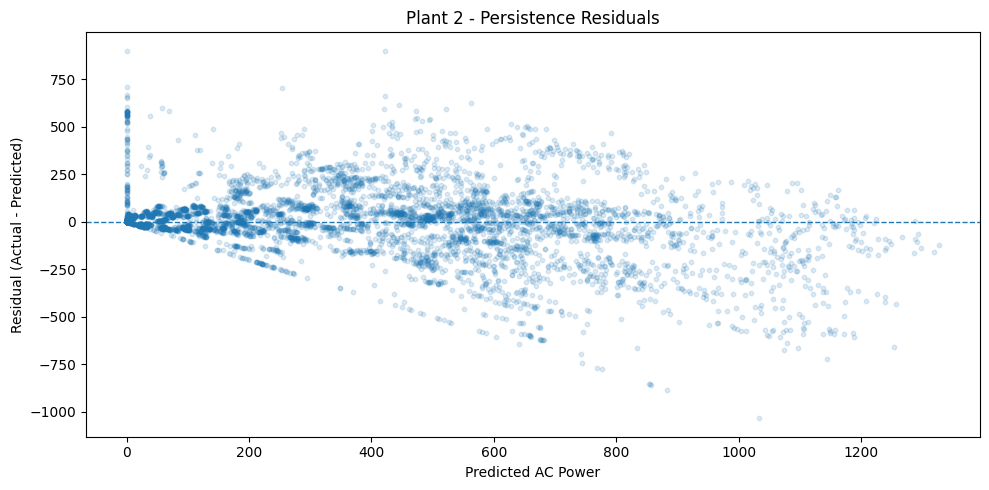

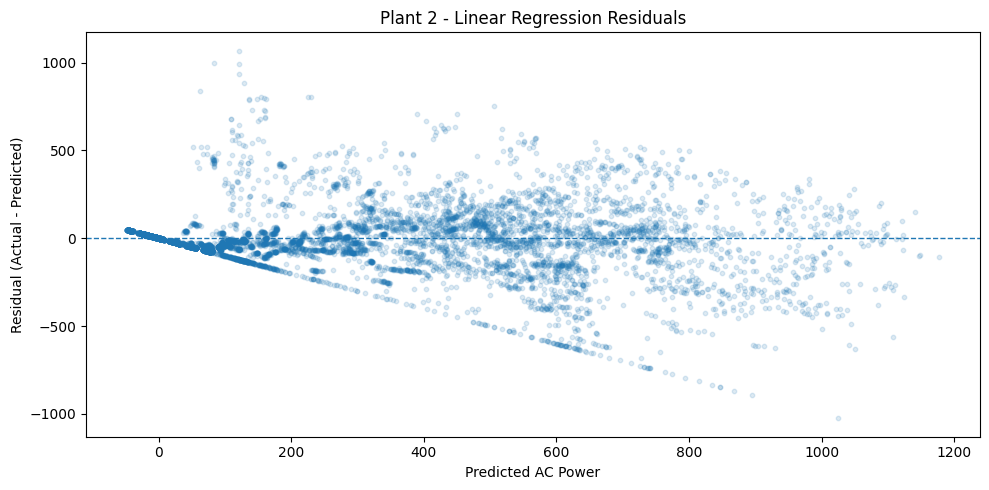

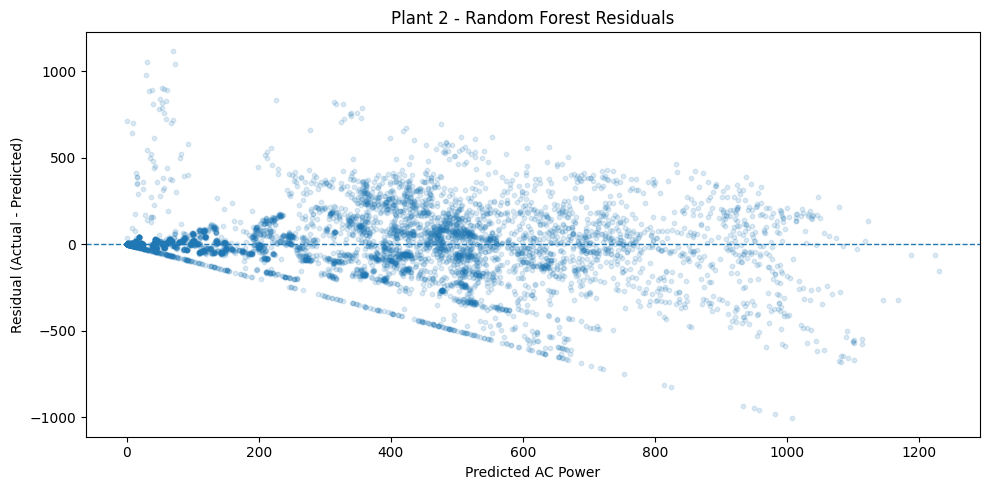

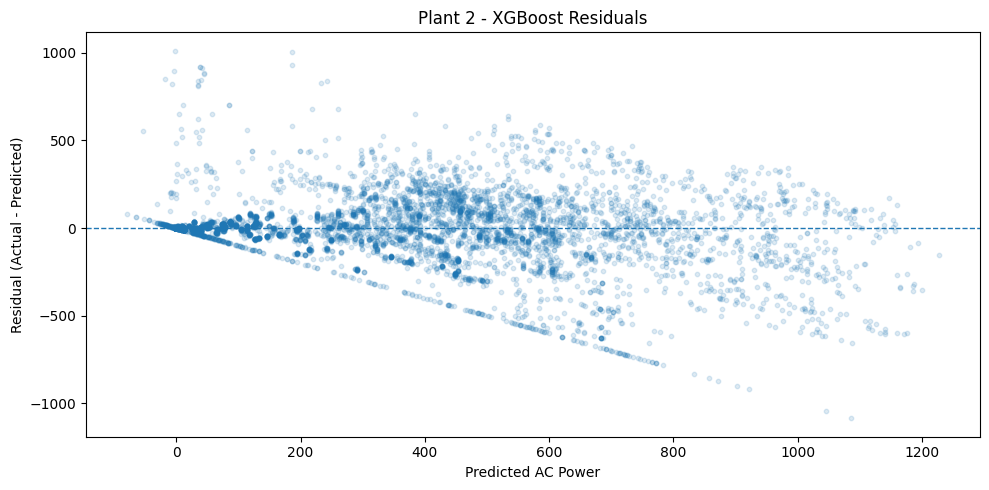

In [21]:
# What this cell does:
# Plot residuals against predicted AC power for Plant 2.
#
# We check whether prediction errors change
# with the level of predicted solar generation.

for model_name, prediction_column, error_column in models:

    plt.figure(figsize=(10, 5))

    plt.scatter(
        plant2_test[prediction_column],
        plant2_test[error_column],
        alpha=0.15,
        s=10
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Predicted AC Power")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"Plant 2 - {model_name} Residuals")
    plt.tight_layout()
    plt.show()

In [22]:
# What this cell does:
# Calculate model MAE separately for every hour of the day.
# This helps identify when the forecasting models make
# larger errors.

plant1_hourly = plant1_test.copy()

plant1_hourly["hour"] = plant1_hourly["DATE_TIME"].dt.hour

hourly_mae_p1 = plant1_hourly.groupby("hour").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"], df["XGBoost"]
        )
    })
)

hourly_mae_p1

,Persistence,Linear Regression,Random Forest,XGBoost
hour,,,,
0,0.000000,67.187562,0.000000,0.326187
1,0.000000,39.415589,0.000000,0.343367
2,0.000000,11.559439,0.000000,0.359707
3,0.000000,30.687558,0.000000,0.643073
4,0.000000,69.851225,0.000000,0.827736
5,1.178649,104.076927,1.030070,2.084667
6,46.148907,56.237509,20.490672,15.067450
7,83.045296,57.914937,73.732430,63.875184
8,63.174383,80.965377,103.458949,110.972994


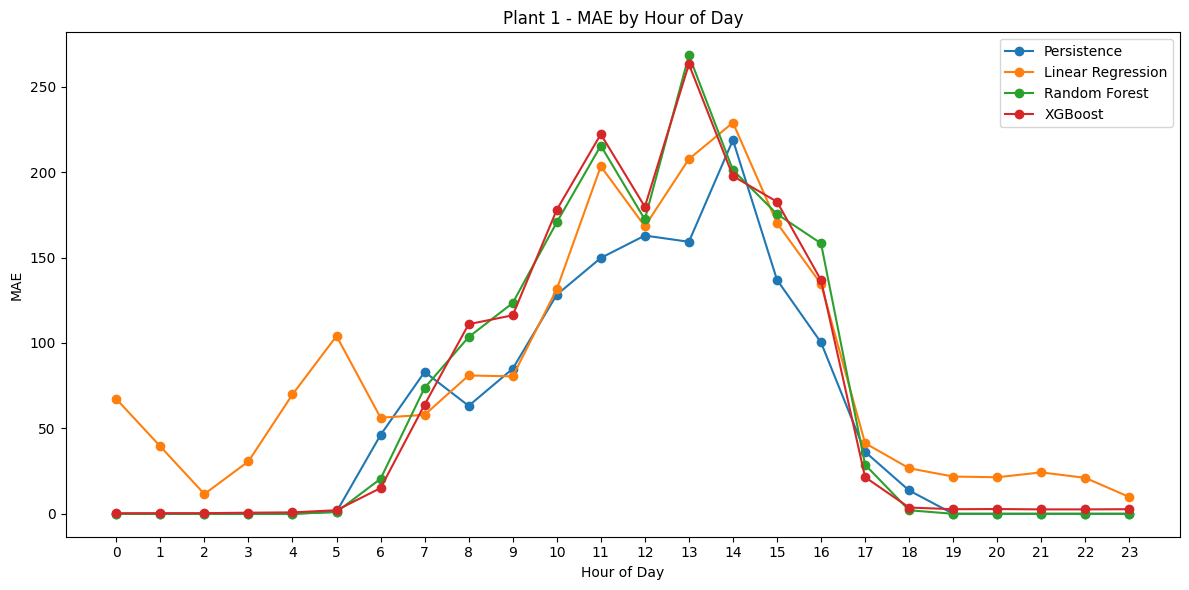

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    hourly_mae_p1.index,
    hourly_mae_p1["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Hour of Day")
plt.ylabel("MAE")
plt.title("Plant 1 - MAE by Hour of Day")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# What this cell does:
# Calculate MAE for each hour of the day for Plant 2.

plant2_hourly = plant2_test.copy()

plant2_hourly["hour"] = plant2_hourly["DATE_TIME"].dt.hour

hourly_mae_p2 = plant2_hourly.groupby("hour").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"], df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"], df["XGBoost"]
        )
    })
)

hourly_mae_p2

,Persistence,Linear Regression,Random Forest,XGBoost
hour,,,,
0,0.000000,43.558149,0.000000,0.212992
1,0.000000,24.220064,0.000000,0.218179
2,0.000000,4.133737,0.000000,0.215962
3,0.000000,23.517974,0.000000,0.218050
4,0.000000,49.189120,0.000000,0.437690
5,1.771114,72.062618,1.532493,2.577080
6,39.849561,37.434675,29.136838,26.653986
7,59.631212,51.472287,60.472053,50.190910
8,100.218523,105.219647,161.115579,152.462907


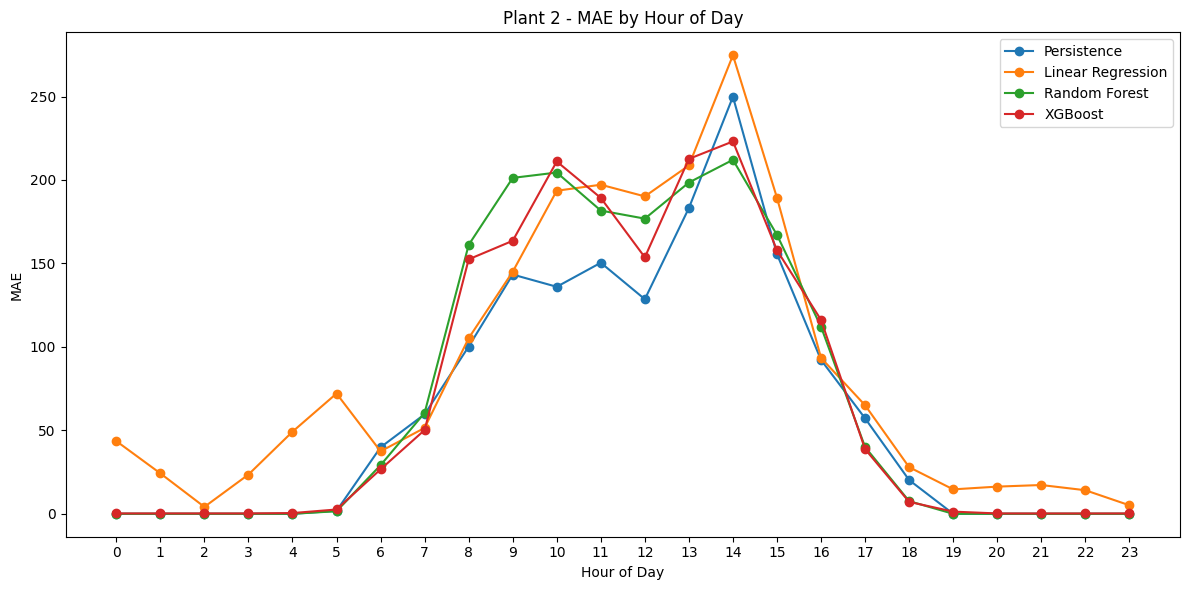

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    hourly_mae_p2.index,
    hourly_mae_p2["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Hour of Day")
plt.ylabel("MAE")
plt.title("Plant 2 - MAE by Hour of Day")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# What this cell does:
# Divide Plant 1 test observations into irradiation ranges
# and calculate model MAE for each range.

plant1_irr = plant1_test.copy()

plant1_irr["irradiation_level"] = pd.cut(
    plant1_irr["IRRADIATION"],
    bins=[-0.001, 0.05, 0.2, 0.5, 1.0, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

irradiation_mae_p1 = plant1_irr.groupby(
    "irradiation_level",
    observed=True
).apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

irradiation_mae_p1

,Persistence,Linear Regression,Random Forest,XGBoost
irradiation_level,,,,
Very Low,3.363713,38.779401,0.980000,2.340128
Low,55.823022,74.039259,83.229545,71.780369
Medium,116.597218,127.353548,149.623043,156.684918
High,150.551077,173.126650,183.622929,180.687714
Very High,233.047673,110.242331,297.124587,223.789236


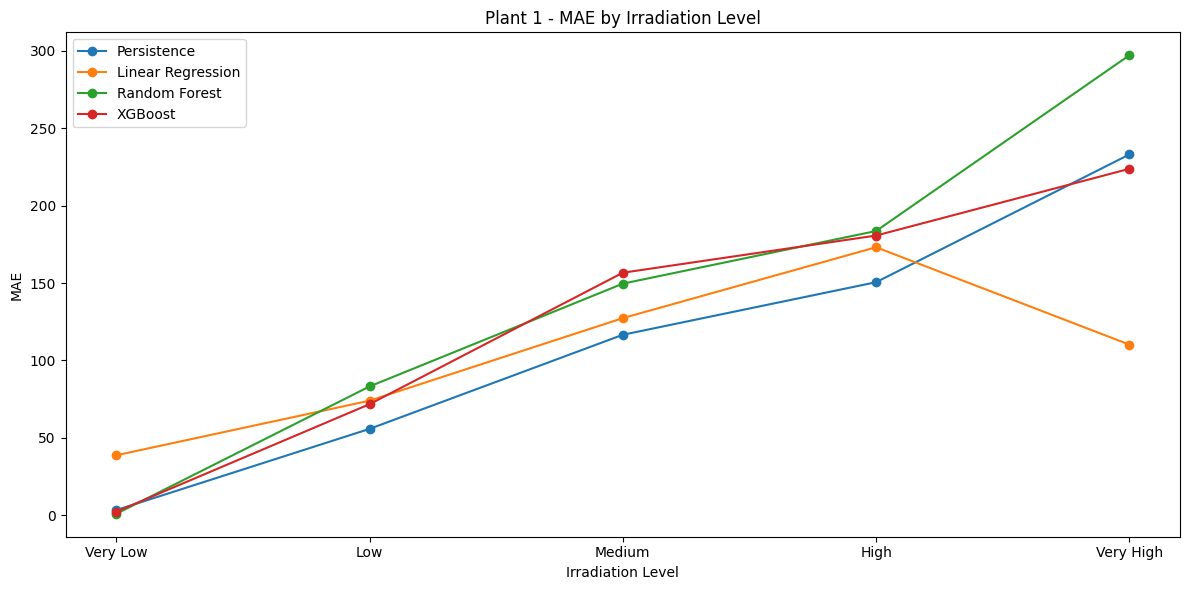

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    irradiation_mae_p1.index,
    irradiation_mae_p1["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Irradiation Level")
plt.ylabel("MAE")
plt.title("Plant 1 - MAE by Irradiation Level")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# What this cell does:
# Calculate model MAE for different irradiation levels
# for Plant 2.

plant2_irr = plant2_test.copy()

plant2_irr["irradiation_level"] = pd.cut(
    plant2_irr["IRRADIATION"],
    bins=[-0.001, 0.05, 0.2, 0.5, 1.0, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

irradiation_mae_p2 = plant2_irr.groupby(
    "irradiation_level",
    observed=True
).apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

irradiation_mae_p2

,Persistence,Linear Regression,Random Forest,XGBoost
irradiation_level,,,,
Very Low,3.323732,27.046837,1.946015,2.246345
Low,63.776236,67.923245,89.405489,79.173697
Medium,148.684414,162.412507,155.796136,156.853130
High,159.833325,209.204510,203.923874,196.136428


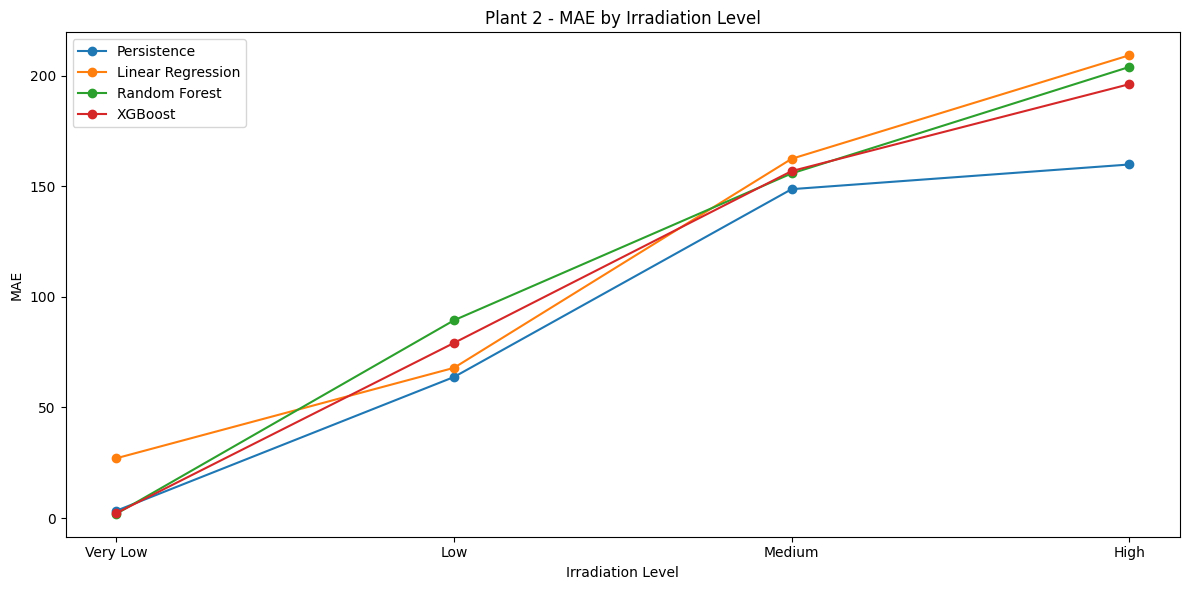

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["Persistence"],
    marker="o",
    label="Persistence"
)

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["Random Forest"],
    marker="o",
    label="Random Forest"
)

plt.plot(
    irradiation_mae_p2.index,
    irradiation_mae_p2["XGBoost"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Irradiation Level")
plt.ylabel("MAE")
plt.title("Plant 2 - MAE by Irradiation Level")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# What this cell does:
# Calculate MAE for each inverter (SOURCE_KEY)
# for all forecasting models on Plant 1 test data.

plant1_inverter_mae = plant1_test.groupby("SOURCE_KEY").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

plant1_inverter_mae

,Persistence,Linear Regression,Random Forest,XGBoost
SOURCE_KEY,,,,
1BY6WEcLGh8j5v7,57.924064,86.154972,79.774246,77.419428
1IF53ai7Xc0U56Y,59.929382,87.181774,74.512612,72.865259
3PZuoBAID5Wc2HD,65.038490,87.286187,75.463062,75.340218
7JYdWkrLSPkdwr4,60.283718,85.400597,75.248812,74.102385
McdE0feGgRqW7Ca,59.648670,84.759322,73.253769,73.471086
VHMLBKoKgIrUVDU,63.087492,87.862059,74.987976,74.499438
WRmjgnKYAwPKWDb,64.676146,87.559488,77.283305,76.560015
YxYtjZvoooNbGkE,61.786299,85.657460,75.358361,76.689016
ZnxXDlPa8U1GXgE,60.847684,85.311598,72.671891,74.661968


In [31]:
# What this cell does:
# Calculate MAE for each inverter (SOURCE_KEY)
# for all forecasting models on Plant 2 test data.

plant2_inverter_mae = plant2_test.groupby("SOURCE_KEY").apply(
    lambda df: pd.Series({
        "Persistence": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Persistence"]
        ),
        "Linear Regression": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Linear_Regression"]
        ),
        "Random Forest": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["Random_Forest"]
        ),
        "XGBoost": mean_absolute_error(
            df["TARGET_AC_POWER"],
            df["XGBoost"]
        )
    })
)

plant2_inverter_mae

,Persistence,Linear Regression,Random Forest,XGBoost
SOURCE_KEY,,,,
4UPUqMRk7TRMgml,58.383812,91.751141,75.584267,71.573923
81aHJ1q11NBPMrL,72.018811,86.828687,76.326214,75.390523
9kRcWv60rDACzjR,61.548278,84.589538,68.918328,68.821350
Et9kgGMDl729KT4,54.818660,85.915860,72.143474,71.226499
IQ2d7wF4YD8zU1Q,68.251846,89.104006,76.905533,72.059796
LYwnQax7tkwH5Cb,67.552714,82.513969,69.110930,68.087086
LlT2YUhhzqhg5Sw,62.327910,85.596304,68.070799,68.011255
Mx2yZCDsyf6DPfv,57.342268,84.811539,69.469497,69.445153
NgDl19wMapZy17u,69.491871,90.926122,80.048537,77.657734


In [32]:
# What this cell does:
# Save inverter-level model performance
# for later analysis and the final report.

TABLES_PATH = "../outputs/tables/"
os.makedirs(TABLES_PATH, exist_ok=True)

plant1_inverter_mae.to_csv(
    TABLES_PATH + "plant1_inverter_mae.csv"
)

plant2_inverter_mae.to_csv(
    TABLES_PATH + "plant2_inverter_mae.csv"
)

print("Inverter-level MAE results saved successfully.")

Inverter-level MAE results saved successfully.


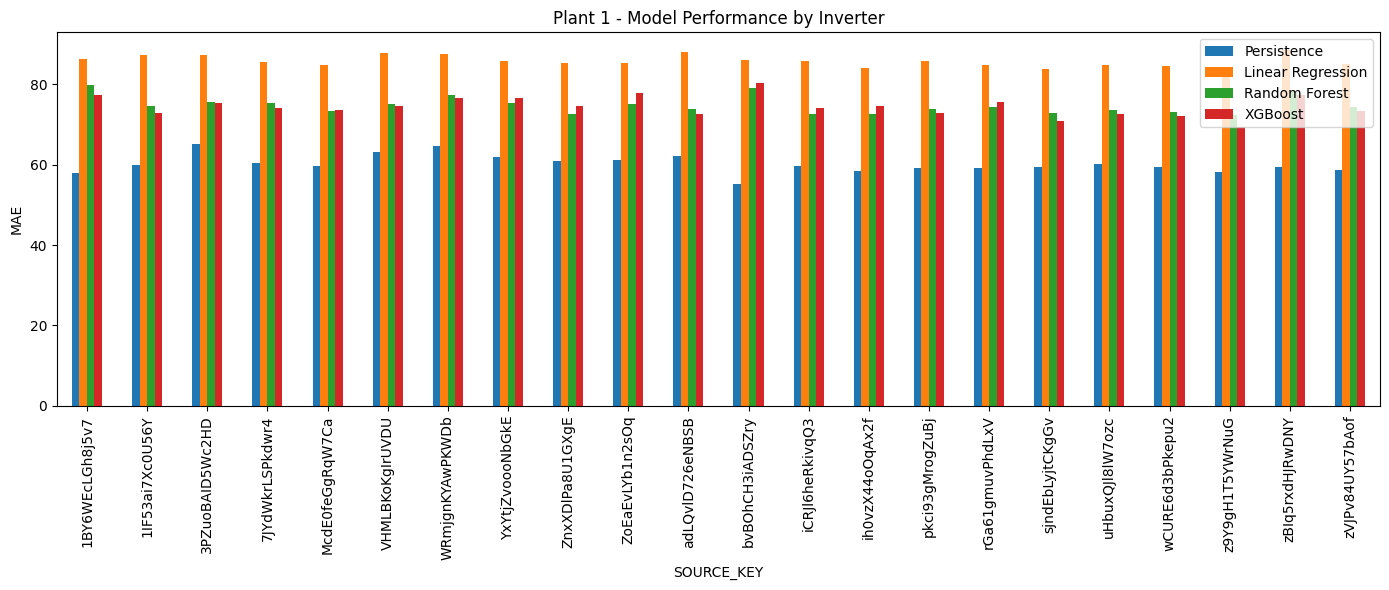

In [33]:
# What this cell does:
# Compare model MAE across individual inverters for Plant 1.

plant1_inverter_mae.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.xlabel("SOURCE_KEY")
plt.ylabel("MAE")
plt.title("Plant 1 - Model Performance by Inverter")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

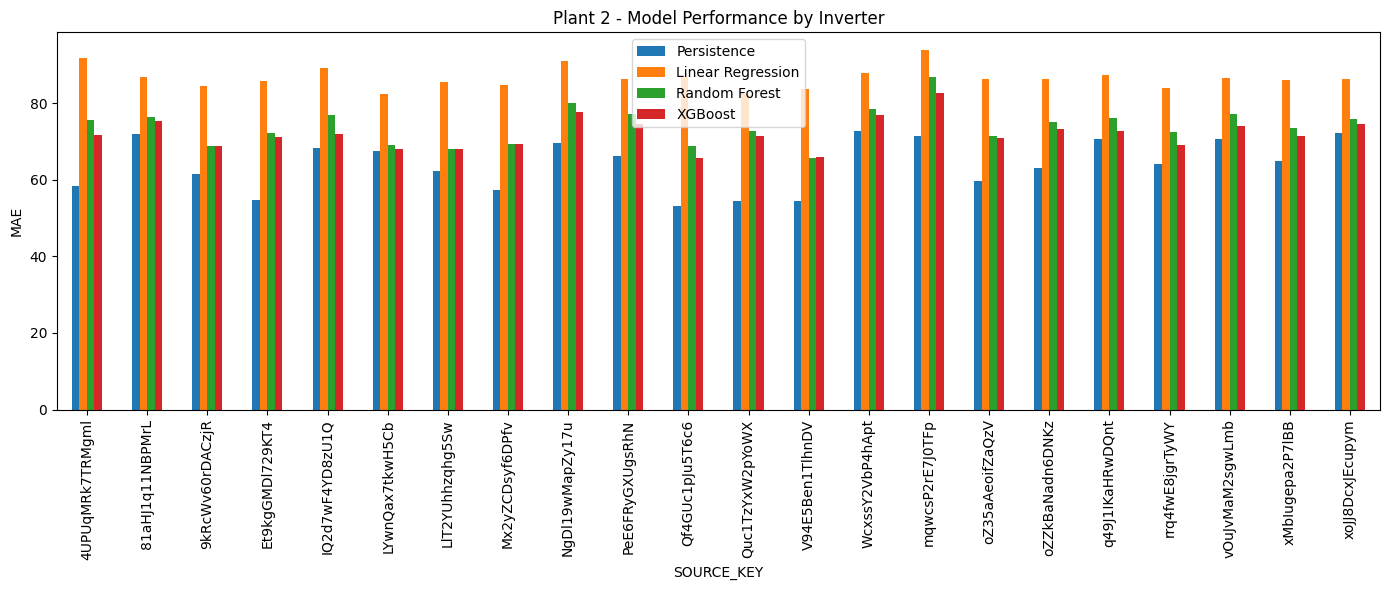

In [34]:
# What this cell does:
# Compare model MAE across individual inverters for Plant 2.

plant2_inverter_mae.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.xlabel("SOURCE_KEY")
plt.ylabel("MAE")
plt.title("Plant 2 - Model Performance by Inverter")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# What this cell does:
# Calculate and summarize final TEST performance
# for all models on Plant 1 and Plant 2.

def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2


# -----------------------------
# Plant 1
# -----------------------------

p1_persistence = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["Persistence"]
)

p1_linear = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["Linear_Regression"]
)

p1_rf = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["Random_Forest"]
)

p1_xgb = get_metrics(
    plant1_test["TARGET_AC_POWER"],
    plant1_test["XGBoost"]
)


# -----------------------------
# Plant 2
# -----------------------------

p2_persistence = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["Persistence"]
)

p2_linear = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["Linear_Regression"]
)

p2_rf = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["Random_Forest"]
)

p2_xgb = get_metrics(
    plant2_test["TARGET_AC_POWER"],
    plant2_test["XGBoost"]
)


# -----------------------------
# Create final comparison table
# -----------------------------

final_model_results = pd.DataFrame({

    "Plant": [
        "Plant 1",
        "Plant 1",
        "Plant 1",
        "Plant 1",
        "Plant 2",
        "Plant 2",
        "Plant 2",
        "Plant 2"
    ],

    "Model": [
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Persistence",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        p1_persistence[0],
        p1_linear[0],
        p1_rf[0],
        p1_xgb[0],
        p2_persistence[0],
        p2_linear[0],
        p2_rf[0],
        p2_xgb[0]
    ],

    "RMSE": [
        p1_persistence[1],
        p1_linear[1],
        p1_rf[1],
        p1_xgb[1],
        p2_persistence[1],
        p2_linear[1],
        p2_rf[1],
        p2_xgb[1]
    ],

    "R2": [
        p1_persistence[2],
        p1_linear[2],
        p1_rf[2],
        p1_xgb[2],
        p2_persistence[2],
        p2_linear[2],
        p2_rf[2],
        p2_xgb[2]
    ]
})

final_model_results

,Plant,Model,MAE,RMSE,R2
0,Plant 1,Persistence,60.149400,113.231793,0.911274
1,Plant 1,Linear Regression,85.727371,131.524724,0.880290
2,Plant 1,Random Forest,74.732041,141.512564,0.861418
3,Plant 1,XGBoost,74.508667,144.273410,0.855958
4,Plant 2,Persistence,64.053122,132.336049,0.802912
5,Plant 2,Linear Regression,86.629786,149.627705,0.748042
6,Plant 2,Random Forest,73.999802,149.392526,0.748834
7,Plant 2,XGBoost,72.086987,148.234218,0.752713


In [36]:
# What this cell does:
# Save the final test-set model comparison.

METRICS_PATH = "../outputs/metrics/"
os.makedirs(METRICS_PATH, exist_ok=True)

final_model_results.to_csv(
    METRICS_PATH + "final_model_results.csv",
    index=False
)

print("Final model results saved successfully.")

Final model results saved successfully.


In [37]:
# What this cell does:
# Find the model with the lowest MAE separately
# for Plant 1 and Plant 2.

best_models = (
    final_model_results
    .loc[final_model_results.groupby("Plant")["MAE"].idxmin()]
    .reset_index(drop=True)
)

print("Best model based on MAE:")
display(best_models)

Best model based on MAE:


,Plant,Model,MAE,RMSE,R2
0,Plant 1,Persistence,60.149400,113.231793,0.911274
1,Plant 2,Persistence,64.053122,132.336049,0.802912


One important correction before we start
For the Digital Twin, we should not simply use the persistence model and stop there. We need to preserve the forecasting-model comparison and then construct the expected-power engine in a way that supports the later inverter anomaly detection and scenario simulation stages.
So don't create any new model yet.